In [4]:
# Cell 1 — imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, roc_auc_score)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

sns.set_theme(style="whitegrid")
print("Libraries loaded")

Libraries loaded


In [5]:
# load data, split and apply SMOTE
df = pd.read_csv('../data/processed_data.csv')

X = df.drop('isFraud', axis=1)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Applying SMOTE")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Training set after SMOTE: {X_train_smote.shape[0]:,} rows")
print(f"Fraud: {y_train_smote.sum():,} | Legitimate: {(y_train_smote==0).sum():,}")

Applying SMOTE
Training set after SMOTE: 4,419,514 rows
Fraud: 2,209,757 | Legitimate: 2,209,757


In [6]:
# train XGBoost
print("Training XGBoost")

xgb_model = xgb.XGBClassifier(
    n_estimators=100,        # 100 sequential trees
    max_depth=6,             # each tree asks max 6 questions
    learning_rate=0.1,       # how much each tree corrects mistakes
    subsample=0.8,           # each tree sees 80% of training rows
    colsample_bytree=0.8,    # each tree sees 80% of features
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_model.fit(X_train_smote, y_train_smote)
print("XGBoost trained")

Training XGBoost
XGBoost trained


In [7]:
# evaluate XGBoost
y_pred_xgb = xgb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)
roc_auc = roc_auc_score(y_test, y_pred_xgb)

print("=" * 50)
print("FULL MODEL COMPARISON")
print("=" * 50)
print(f"{'Metric':<12} {'Logistic':>12} {'RF+SMOTE':>12} {'XGBoost':>12}")
print("-" * 50)
print(f"{'Recall':<12} {'0.4461':>12} {'0.9976':>12} {recall:>12.4f}")
print(f"{'Precision':<12} {'0.8435':>12} {'0.9540':>12} {precision:>12.4f}")
print(f"{'F1':<12} {'0.5836':>12} {'0.9753':>12} {f1:>12.4f}")
print(f"{'ROC-AUC':<12} {'0.7229':>12} {'0.9987':>12} {roc_auc:>12.4f}")
print("=" * 50)

FULL MODEL COMPARISON
Metric           Logistic     RF+SMOTE      XGBoost
--------------------------------------------------
Recall             0.4461       0.9976       0.9963
Precision          0.8435       0.9540       0.9468
F1                 0.5836       0.9753       0.9709
ROC-AUC            0.7229       0.9987       0.9981


In [9]:
# SHAP setup
print("Calculating SHAP values")

# 500 fraud + 500 legitimate for balanced analysis
fraud_sample = X_test[y_test == 1].sample(500, random_state=42)
legit_sample = X_test[y_test == 0].sample(500, random_state=42)
X_shap = pd.concat([fraud_sample, legit_sample])

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

print("SHAP values calculated")

Calculating SHAP values
SHAP values calculated


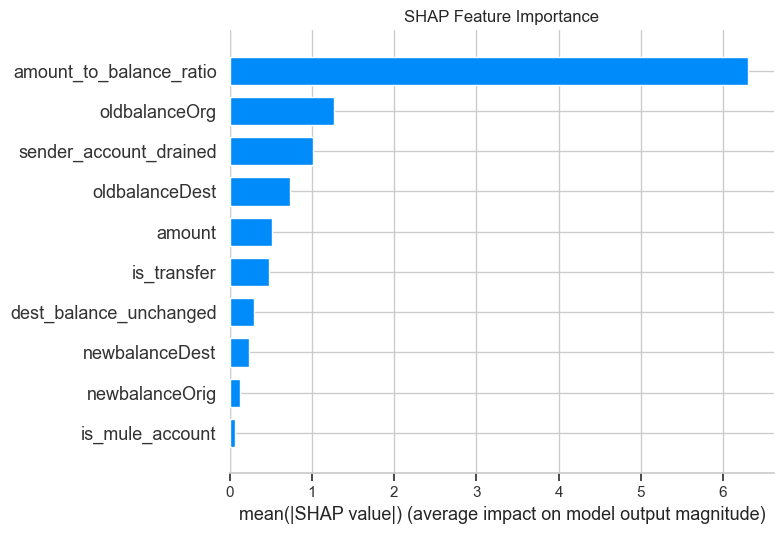

SHAP summary plot saved ✓


In [10]:
# SHAP summary plot
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=False
)
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.savefig('../notebooks/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary plot saved ✓")

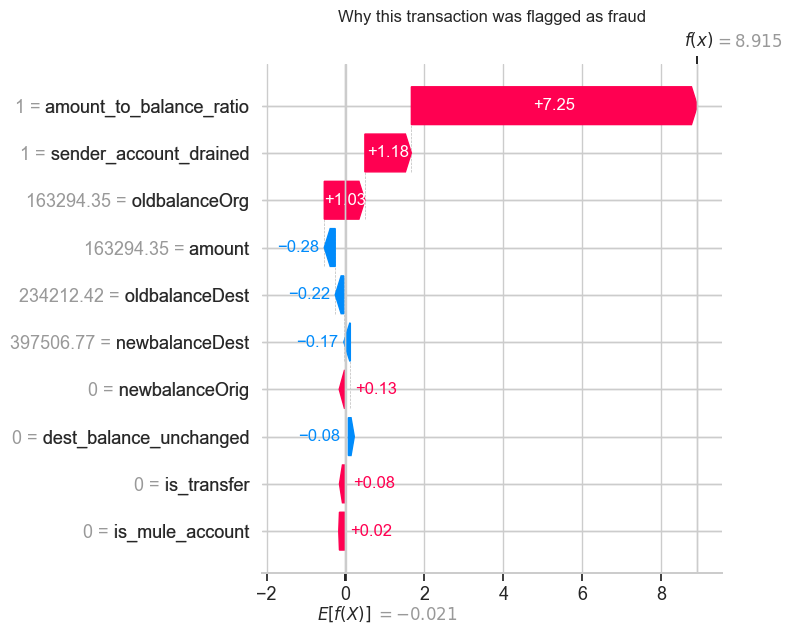

Waterfall plot saved 


In [12]:
# SHAP waterfall plot for one fraud transaction
# get index of first fraud case in our shap sample
fraud_idx = 0  # first row is a fraud case since we put fraud first

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[fraud_idx],
        base_values=explainer.expected_value,
        data=X_shap.iloc[fraud_idx],
        feature_names=X_shap.columns.tolist()
    ),
    show=False
)
plt.title('Why this transaction was flagged as fraud')
plt.tight_layout()
plt.savefig('../notebooks/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Waterfall plot saved ")

In [14]:
# save final model
import joblib

joblib.dump(xgb_model, '../models/xgboost_fraud.joblib')
joblib.dump(explainer, '../models/shap_explainer.joblib')
print("XGBoost model saved ")
print("SHAP explainer saved ")

XGBoost model saved 
SHAP explainer saved 
